In [30]:
%pip install missingno


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: /opt/homebrew/Cellar/jupyterlab/4.4.7/libexec/bin/python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
merged = pd.read_csv(
    "/Users/kachi/Documents/Thesis/data/processed/fbref_transfermarkt_merged.csv"
)

merged.head()

,league,season,club,player_name,nation,position_fbref,age_fbref,born,matches_played,starts,...,clean_sheets,clean_sheet_percentage,penalties_faced,penalties_saved,penalties_missed,penalties_conceded,penalty_save_percentage,position_tm,age_tm,market_value_eur
0,ENG-Premier League,2122.0,Arsenal,aaron ramsdale,ENG,GK,23.0,1998.0,34,34,...,12.0,35.3,6.0,5.0,0.0,1.0,0.0,Goalkeeper,24.0,28000000.0
1,ENG-Premier League,2122.0,Arsenal,ainsley maitland niles,ENG,MF,23.0,1997.0,8,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Right-Back,24.0,10000000.0
2,ENG-Premier League,2122.0,Arsenal,albert sambi lokonga,BEL,MF,21.0,1999.0,19,12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Central Midfield,22.0,14000000.0
3,ENG-Premier League,2122.0,Arsenal,alexandre lacazette,FRA,"FW,MF",30.0,1991.0,30,20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Centre-Forward,31.0,15000000.0
4,ENG-Premier League,2122.0,Arsenal,ben white,ENG,DF,23.0,1997.0,32,32,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Right-Back,24.0,40000000.0


In [3]:
merged.shape

(2269, 71)

In [13]:
merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2269 entries, 0 to 2268
Data columns (total 71 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   league                    2269 non-null   object 
 1   season                    2269 non-null   float64
 2   club                      2269 non-null   object 
 3   player_name               2269 non-null   object 
 4   nation                    2267 non-null   object 
 5   position_fbref            2269 non-null   object 
 6   age_fbref                 2268 non-null   float64
 7   born                      2268 non-null   float64
 8   matches_played            2269 non-null   int64  
 9   starts                    2269 non-null   int64  
 10  minutes                   2269 non-null   int64  
 11  nineties                  2269 non-null   float64
 12  goals                     2269 non-null   int64  
 13  assists                   2269 non-null   int64  
 14  goal_con

In [14]:
merged.head()

,league,season,club,player_name,nation,position_fbref,age_fbref,born,matches_played,starts,...,clean_sheets,clean_sheet_percentage,penalties_faced,penalties_saved,penalties_missed,penalties_conceded,penalty_save_percentage,position_tm,age_tm,market_value_eur
0,ENG-Premier League,2122.0,Arsenal,aaron ramsdale,ENG,GK,23.0,1998.0,34,34,...,12.0,35.3,6.0,5.0,0.0,1.0,0.0,Goalkeeper,24.0,28000000.0
1,ENG-Premier League,2122.0,Arsenal,ainsley maitland niles,ENG,MF,23.0,1997.0,8,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Right-Back,24.0,10000000.0
2,ENG-Premier League,2122.0,Arsenal,albert sambi lokonga,BEL,MF,21.0,1999.0,19,12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Central Midfield,22.0,14000000.0
3,ENG-Premier League,2122.0,Arsenal,alexandre lacazette,FRA,"FW,MF",30.0,1991.0,30,20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Centre-Forward,31.0,15000000.0
4,ENG-Premier League,2122.0,Arsenal,ben white,ENG,DF,23.0,1997.0,32,32,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Right-Back,24.0,40000000.0


In [15]:
merged.columns.tolist()

['league',
 'season',
 'club',
 'player_name',
 'nation',
 'position_fbref',
 'age_fbref',
 'born',
 'matches_played',
 'starts',
 'minutes',
 'nineties',
 'goals',
 'assists',
 'goal_contributions',
 'non_penalty_goals',
 'penalty_goals',
 'penalty_attempts',
 'yellow_cards',
 'red_cards',
 'goals_per90',
 'assists_per90',
 'ga_per90',
 'npg_per90',
 'npga_per90',
 'shots',
 'shots_on_target',
 'shots_on_target_pct',
 'shots_per90',
 'shots_on_target_per90',
 'goals_per_shot',
 'goals_per_shot_on_target',
 'minutes_per_match',
 'minutes_pct',
 'starts_per_match',
 'complete_matches',
 'substitute_appearances',
 'minutes_per_sub',
 'unused_substitute',
 'points_per_match',
 'team_goals',
 'team_goals_against',
 'goal_difference',
 'goal_difference_per90',
 'on_off',
 'second_yellows',
 'fouls_committed',
 'fouls_drawn',
 'offsides',
 'crosses',
 'interceptions',
 'tackles_won',
 'own_goals',
 'goals_against',
 'goals_against_per90',
 'shots_on_target_against',
 'saves',
 'save_percenta

In [16]:
summary = pd.DataFrame({
    "Metric": [
        "Number of observations",
        "Number of variables",
        "Numeric variables",
        "Categorical variables"
    ],
    "Value": [
        merged.shape[0],
        merged.shape[1],
        merged.select_dtypes(include=np.number).shape[1],
        merged.select_dtypes(exclude=np.number).shape[1]
    ]
})

summary

,Metric,Value
0,Number of observations,2269
1,Number of variables,71
2,Numeric variables,65
3,Categorical variables,6


## Data Quality Assessment (missing values and duplicates)

In [17]:
merged.isnull().sum()

league                        0
season                        0
club                          0
player_name                   0
nation                        2
                           ... 
penalties_conceded         2104
penalty_save_percentage    2155
position_tm                 126
age_tm                      126
market_value_eur            153
Length: 71, dtype: int64

In [18]:
# Number of missing values
missing = (
    merged.isnull()
          .sum()
          .sort_values(ascending=False)
)

missing

penalty_save_percentage    2155
clean_sheet_percentage     2109
save_percentage            2105
shots_on_target_against    2104
penalties_faced            2104
                           ... 
minutes_per_match             0
minutes_pct                   0
season                        0
substitute_appearances        0
complete_matches              0
Length: 71, dtype: int64

In [19]:
missing_pct = (
    merged.isnull()
          .mean() * 100
).sort_values(ascending=False)

missing_pct

penalty_save_percentage    94.975760
clean_sheet_percentage     92.948435
save_percentage            92.772146
shots_on_target_against    92.728074
penalties_faced            92.728074
                             ...    
minutes_per_match           0.000000
minutes_pct                 0.000000
season                      0.000000
substitute_appearances      0.000000
complete_matches            0.000000
Length: 71, dtype: float64

In [20]:
missing_summary = pd.DataFrame({
    "Missing Values": merged.isnull().sum(),
    "Percentage (%)": (
        merged.isnull().mean()*100
    ).round(2)
})

missing_summary = (
    missing_summary[
        missing_summary["Missing Values"] > 0
    ]
    .sort_values(
        "Percentage (%)",
        ascending=False
    )
)

missing_summary

,Missing Values,Percentage (%)
penalty_save_percentage,2155,94.98
clean_sheet_percentage,2109,92.95
save_percentage,2105,92.77
shots_on_target_against,2104,92.73
clean_sheets,2104,92.73
losses,2104,92.73
draws,2104,92.73
wins,2104,92.73
penalties_missed,2104,92.73
saves,2104,92.73


In [21]:
duplicates = merged.duplicated(
    subset=["player_name", "club", "season"]
).sum()

duplicates

np.int64(0)

In [22]:
matched_players = merged["market_value_eur"].notna().sum()

total_players = len(merged)

match_rate = (
    matched_players / total_players
) * 100

print(f"Matched players : {matched_players}")
print(f"Total players   : {total_players}")
print(f"Match rate      : {match_rate:.2f}%")

Matched players : 2116
Total players   : 2269
Match rate      : 93.26%


In [23]:
goalkeepers = merged[
    merged["position_fbref"] == "GK"
]

other_positions = merged[
    merged["position_fbref"] != "GK"
]

print(goalkeepers.shape)
print(other_positions.shape)

(165, 71)
(2104, 71)


In [24]:
goalkeepers[
    [
        "goals_against",
        "saves",
        "clean_sheets"
    ]
].isnull().sum()

goals_against    0
saves            0
clean_sheets     0
dtype: int64

In [25]:
summary_stats = {
    "rows": merged.shape[0],
    "columns": merged.shape[1],
    "duplicates": duplicates,
    "matched": matched_players,
    "match_rate": round(match_rate, 2)
}

summary_stats

{'rows': 2269,
 'columns': 71,
 'duplicates': np.int64(0),
 'matched': np.int64(2116),
 'match_rate': np.float64(93.26)}

In [26]:
merged["league"].value_counts()

league
ENG-Premier League    2269
Name: count, dtype: int64

In [27]:
merged.describe().T[
    ["mean", "std", "min", "max"]
].head(15)

,mean,std,min,max
season,2275.614368,112.347513,2122.0,2425.0
age_fbref,25.178131,4.438773,15.0,39.0
born,1996.943563,4.625965,1981.0,2009.0
matches_played,19.736007,11.869344,1.0,38.0
starts,14.737770,11.966977,0.0,38.0
minutes,1324.103570,1030.479065,1.0,3420.0
nineties,14.711283,11.449333,0.0,38.0
goals,1.918907,3.498367,0.0,36.0
assists,1.381225,2.204017,0.0,18.0
goal_contributions,3.300132,5.116742,0.0,47.0


In [28]:
merged["position_fbref"].value_counts()

position_fbref
MF       708
DF       601
FW       265
MF,FW    170
GK       165
FW,MF    150
DF,MF    134
MF,DF     73
DF,FW      3
Name: count, dtype: int64

In [29]:
merged["season"].value_counts()

season
2324.0    580
2425.0    574
2223.0    569
2122.0    546
Name: count, dtype: int64

In [30]:
merged["position_tm"].value_counts(dropna=False)

position_tm
Centre-Back           394
Centre-Forward        279
Central Midfield      277
Defensive Midfield    193
Right-Back            190
Left Winger           174
Attacking Midfield    163
Goalkeeper            154
Right Winger          145
Left-Back             144
NaN                   126
Left Midfield          13
Right Midfield          9
Second Striker          8
Name: count, dtype: int64

In [31]:
merged.columns

Index(['league', 'season', 'club', 'player_name', 'nation', 'position_fbref',
       'age_fbref', 'born', 'matches_played', 'starts', 'minutes', 'nineties',
       'goals', 'assists', 'goal_contributions', 'non_penalty_goals',
       'penalty_goals', 'penalty_attempts', 'yellow_cards', 'red_cards',
       'goals_per90', 'assists_per90', 'ga_per90', 'npg_per90', 'npga_per90',
       'shots', 'shots_on_target', 'shots_on_target_pct', 'shots_per90',
       'shots_on_target_per90', 'goals_per_shot', 'goals_per_shot_on_target',
       'minutes_per_match', 'minutes_pct', 'starts_per_match',
       'complete_matches', 'substitute_appearances', 'minutes_per_sub',
       'unused_substitute', 'points_per_match', 'team_goals',
       'team_goals_against', 'goal_difference', 'goal_difference_per90',
       'on_off', 'second_yellows', 'fouls_committed', 'fouls_drawn',
       'offsides', 'crosses', 'interceptions', 'tackles_won', 'own_goals',
       'goals_against', 'goals_against_per90', 'shots_on_

## Market Value Distribution

In [32]:
merged["market_value_eur"].describe()

count    2.116000e+03
mean     1.946745e+07
std      2.076568e+07
min      7.500000e+04
25%      5.000000e+06
50%      1.400000e+07
75%      2.500000e+07
max      1.800000e+08
Name: market_value_eur, dtype: float64

In [33]:
merged["market_value_eur"].skew()

np.float64(2.3819571393446344)

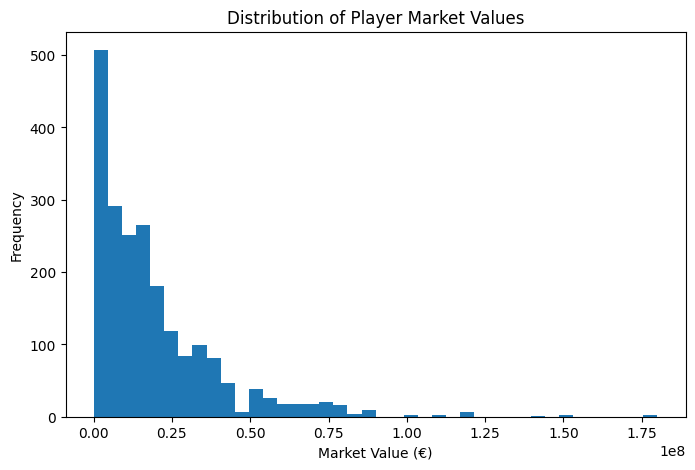

In [34]:
# Histogram to investigate the overall distribution of player market values

plt.figure(figsize=(8,5))
plt.hist(
    merged["market_value_eur"].dropna(),
    bins=40
)

plt.xlabel("Market Value (€)")
plt.ylabel("Frequency")
plt.title("Distribution of Player Market Values")

plt.show()

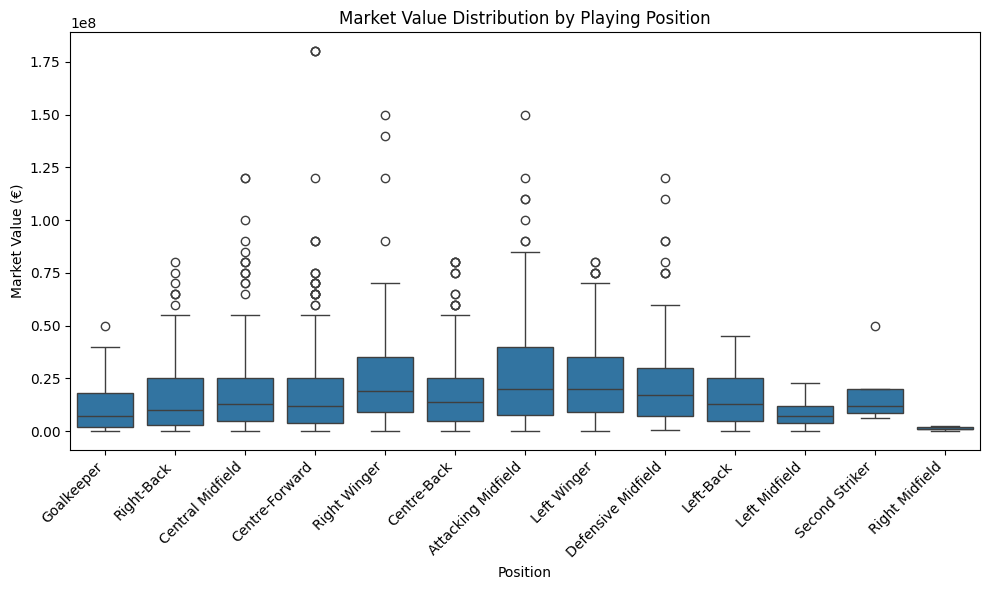

In [35]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=merged,
    x="position_tm",
    y="market_value_eur"
)

plt.xticks(rotation=45, ha="right")

plt.xlabel("Position")
plt.ylabel("Market Value (€)")
plt.title("Market Value Distribution by Playing Position")

plt.tight_layout()
plt.show()

## Outlier Detection

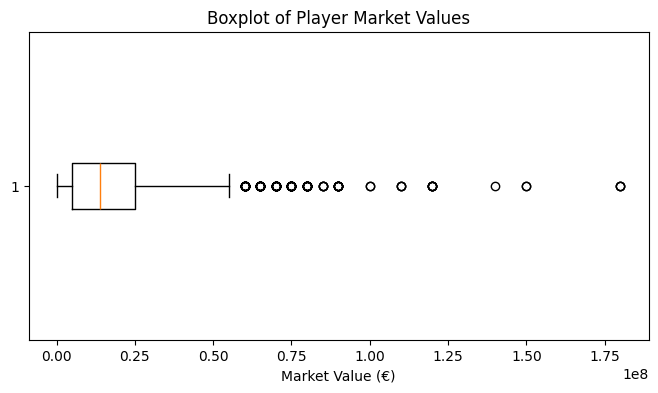

In [36]:
# Boxplot to investigate the overall distribution of player market values and outliers

plt.figure(figsize=(8,4))
plt.boxplot(
    merged["market_value_eur"].dropna(),
    vert=False
)

plt.xlabel("Market Value (€)")
plt.title("Boxplot of Player Market Values")

plt.show()

## Distribution Of Other Key Features
- Age
- Minutes played

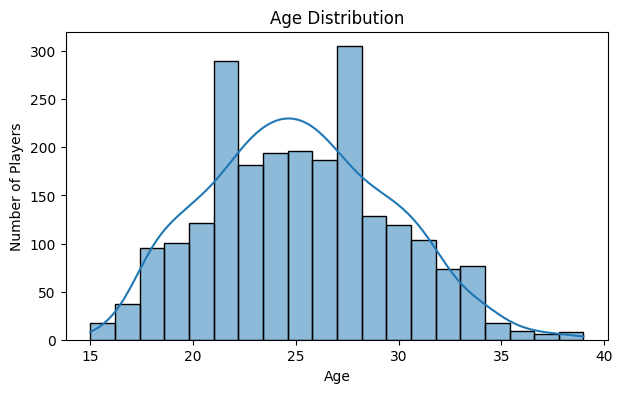

In [37]:
# Age

plt.figure(figsize=(7,4))

sns.histplot(
    merged["age_fbref"],
    bins=20,
    kde=True
)

plt.xlabel("Age")
plt.ylabel("Number of Players")
plt.title("Age Distribution")

plt.show()

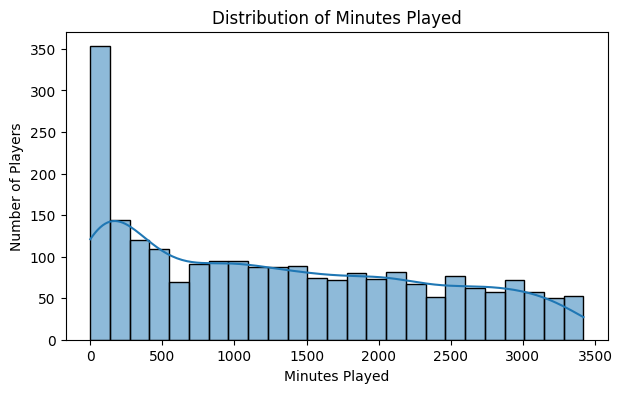

In [38]:
# Minutes Played

plt.figure(figsize=(7,4))

sns.histplot(
    merged["minutes"],
    bins=25,
    kde=True
)

plt.xlabel("Minutes Played")
plt.ylabel("Number of Players")
plt.title("Distribution of Minutes Played")

plt.show()

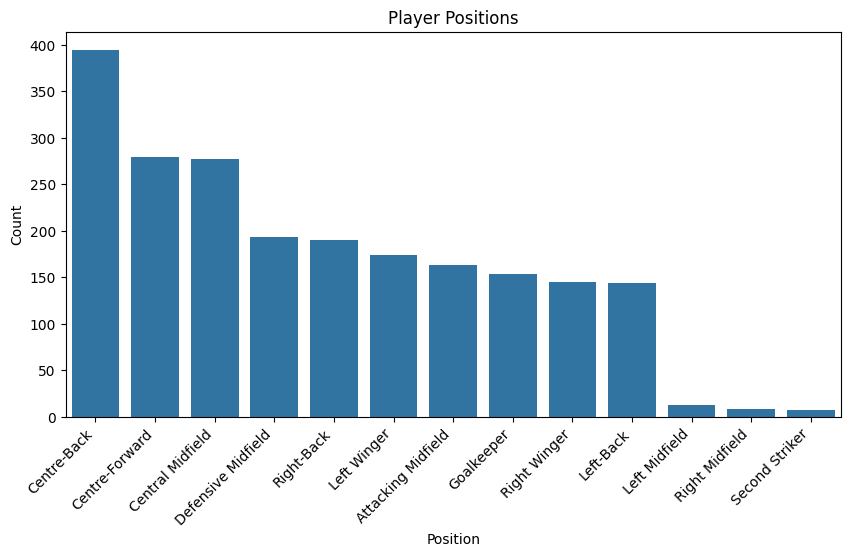

In [39]:
# Position

plt.figure(figsize=(10,5))

sns.countplot(
    data=merged,
    x="position_tm",
    order=merged["position_tm"].value_counts().index
)

plt.xticks(rotation=45, ha="right")

plt.xlabel("Position")
plt.ylabel("Count")

plt.title("Player Positions")

plt.show()

## Unilateral Analysis

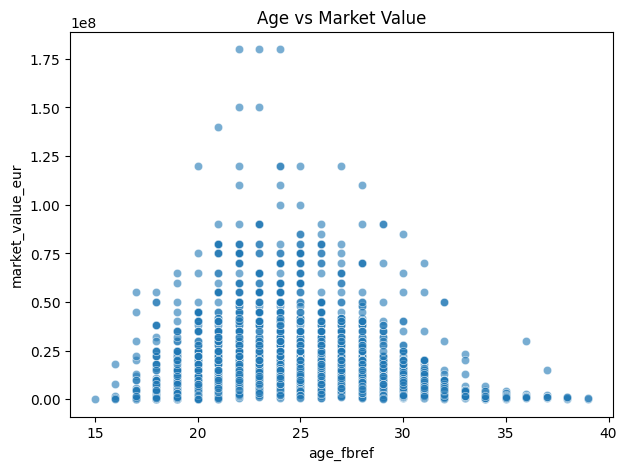

In [51]:
# Relationship between age and market value

plt.figure(figsize=(7,5))

sns.scatterplot(
    data=merged,
    x="age_fbref",
    y="market_value_eur",
    alpha=0.6
)

plt.title("Age vs Market Value")

plt.show()

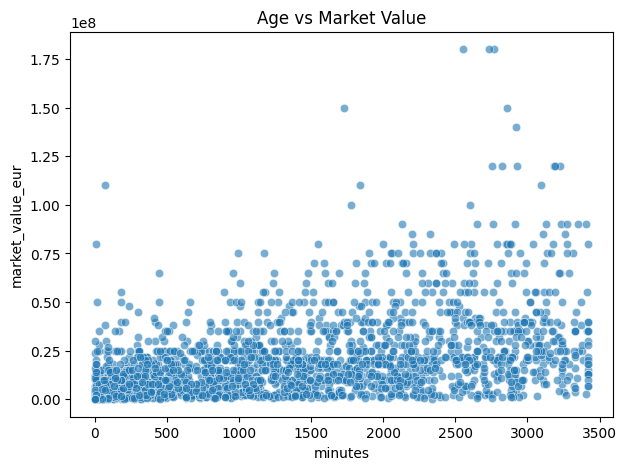

In [52]:
# Relationship between minutes and market value

plt.figure(figsize=(7,5))

sns.scatterplot(
    data=merged,
    x="minutes",
    y="market_value_eur",
    alpha=0.6
)

plt.title("Age vs Market Value")

plt.show()

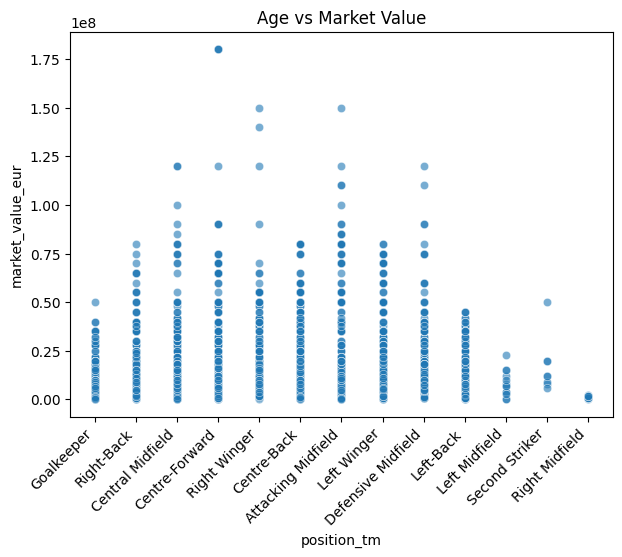

In [54]:
# Relationship between playing positions and market value

plt.figure(figsize=(7,5))

sns.scatterplot(
    data=merged,
    x="position_tm",
    y="market_value_eur",
    alpha=0.6
)
plt.xticks(rotation=45, ha="right")

plt.title("Age vs Market Value")

plt.show()

In [29]:
Q1 = merged["market_value_eur"].quantile(0.25)
Q3 = merged["market_value_eur"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = merged[
    (merged["market_value_eur"] < lower) |
    (merged["market_value_eur"] > upper)
]

len(outliers)

120

In [30]:
outliers.sort_values(
    "market_value_eur",
    ascending=False
)[
    [
        "player_name",
        "club",
        "market_value_eur",
        "position_tm"
    ]
].head(20)

,player_name,club,market_value_eur,position_tm
1461,erling haaland,Manchester City,180000000.0,Centre-Forward
887,erling haaland,Manchester City,180000000.0,Centre-Forward
2040,erling haaland,Manchester City,180000000.0,Centre-Forward
1696,bukayo saka,Arsenal,150000000.0,Right Winger
1476,phil foden,Manchester City,150000000.0,Attacking Midfield
1117,bukayo saka,Arsenal,140000000.0,Right Winger
549,bukayo saka,Arsenal,120000000.0,Right Winger
1478,rodri,Manchester City,120000000.0,Defensive Midfield
1840,cole palmer,Chelsea,120000000.0,Attacking Midfield
1120,declan rice,Arsenal,120000000.0,Central Midfield


## Missing Value Patterns

<Figure size 1400x600 with 0 Axes>

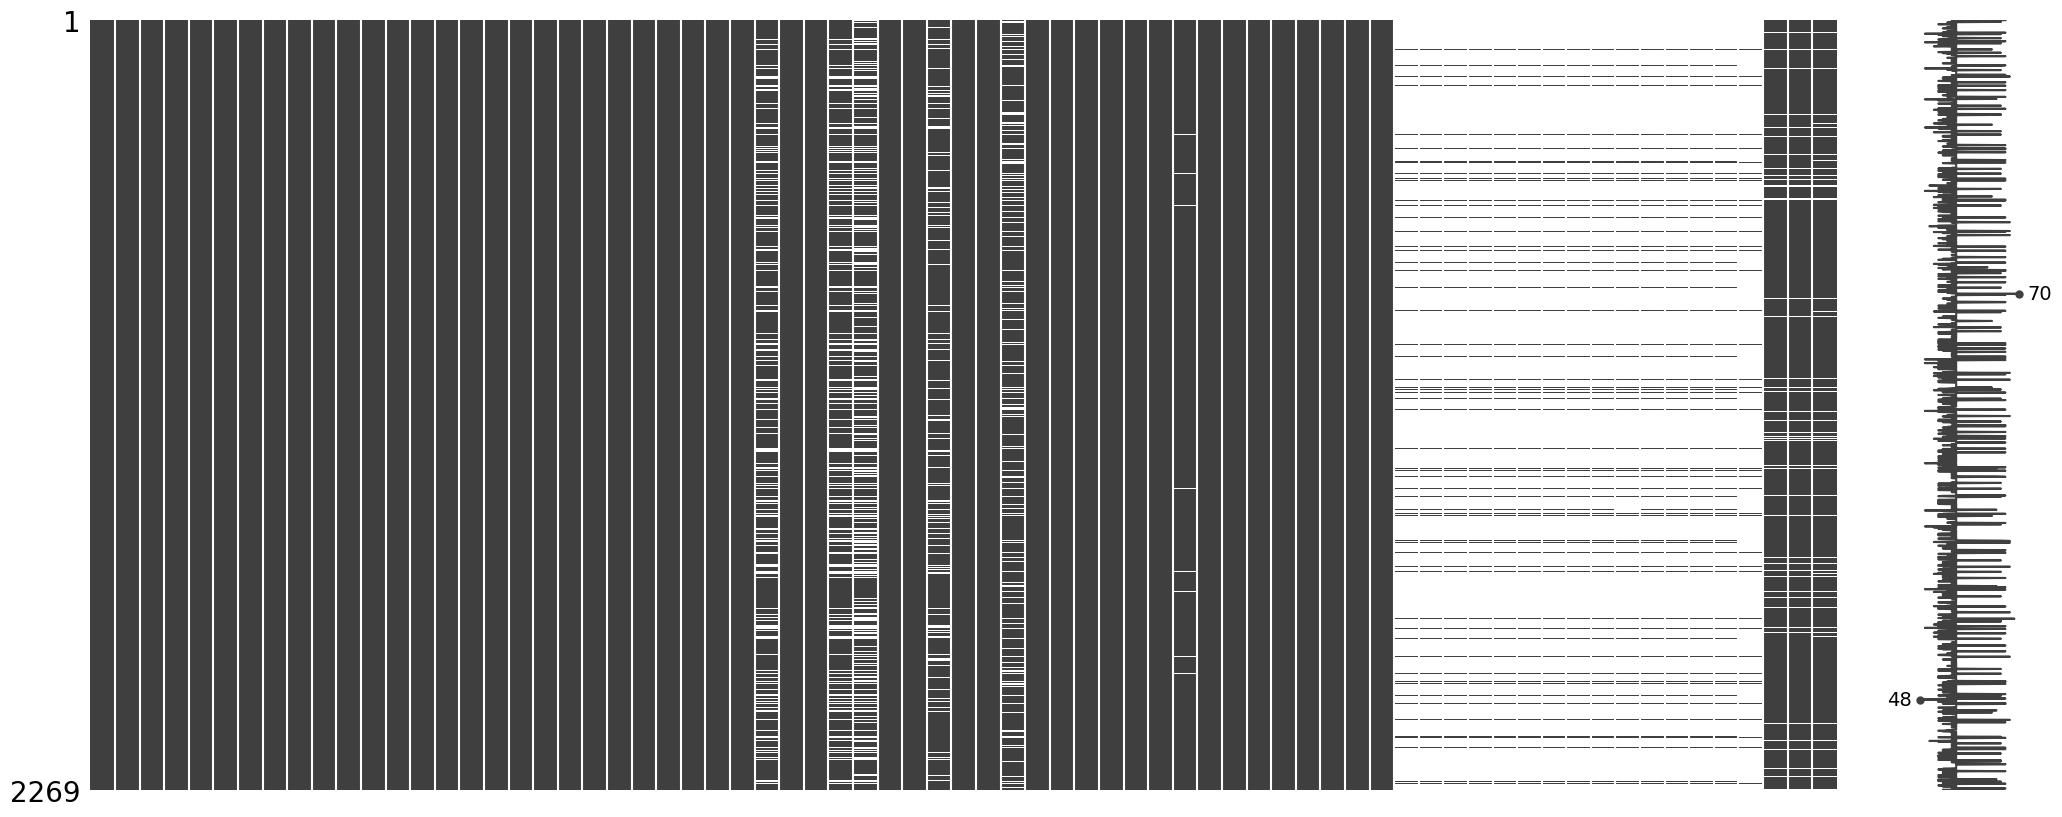

In [31]:
plt.figure(figsize=(14,6))
msno.matrix(merged)
plt.show()

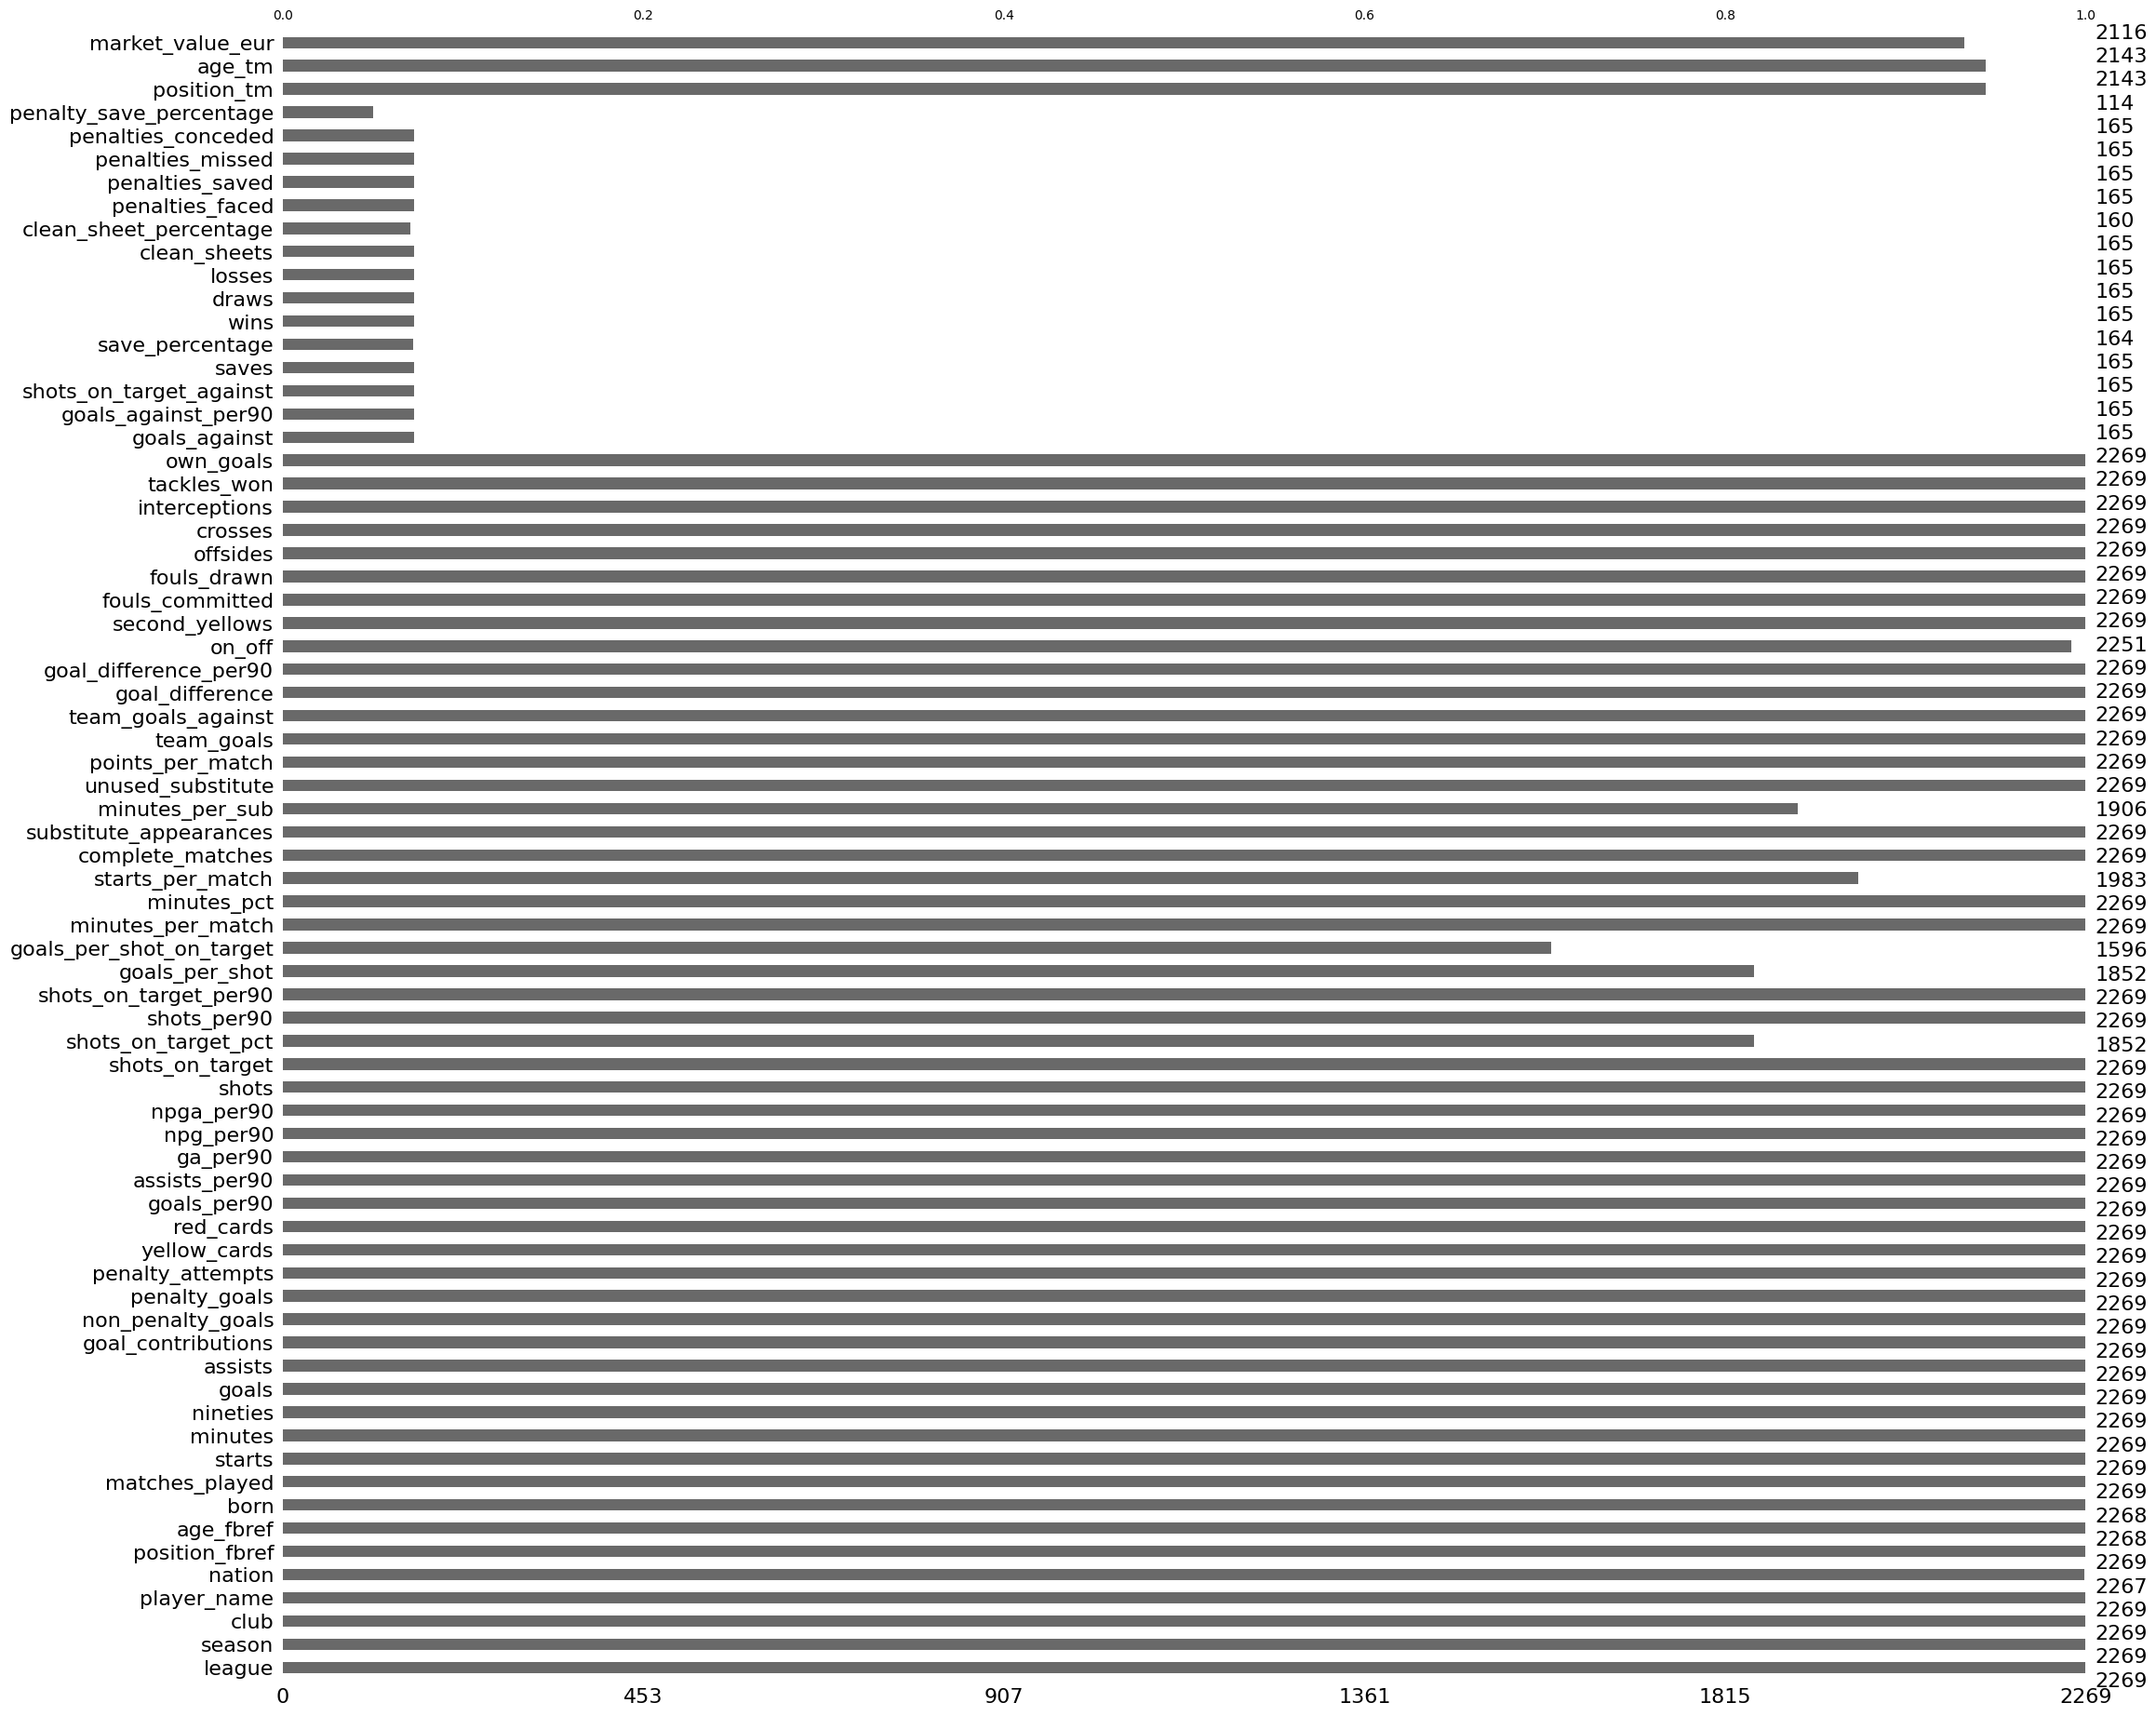

In [32]:
plt.figure(figsize=(12,6))
msno.bar(merged)
plt.show()

<Axes: >

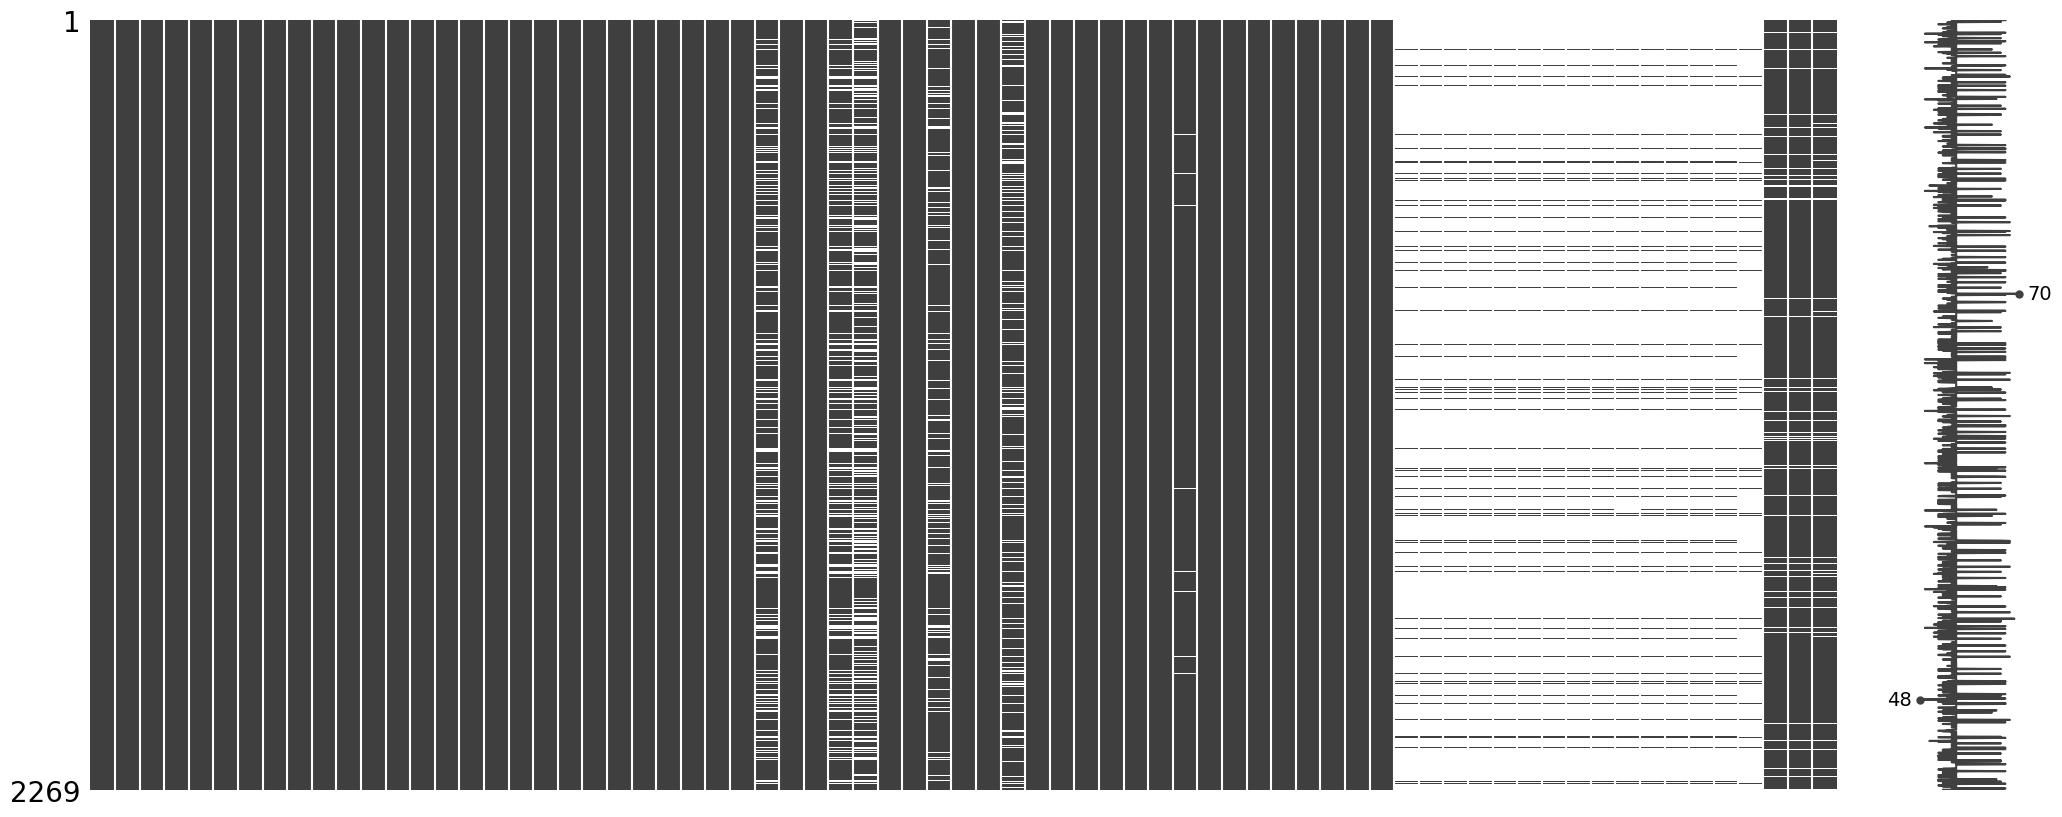

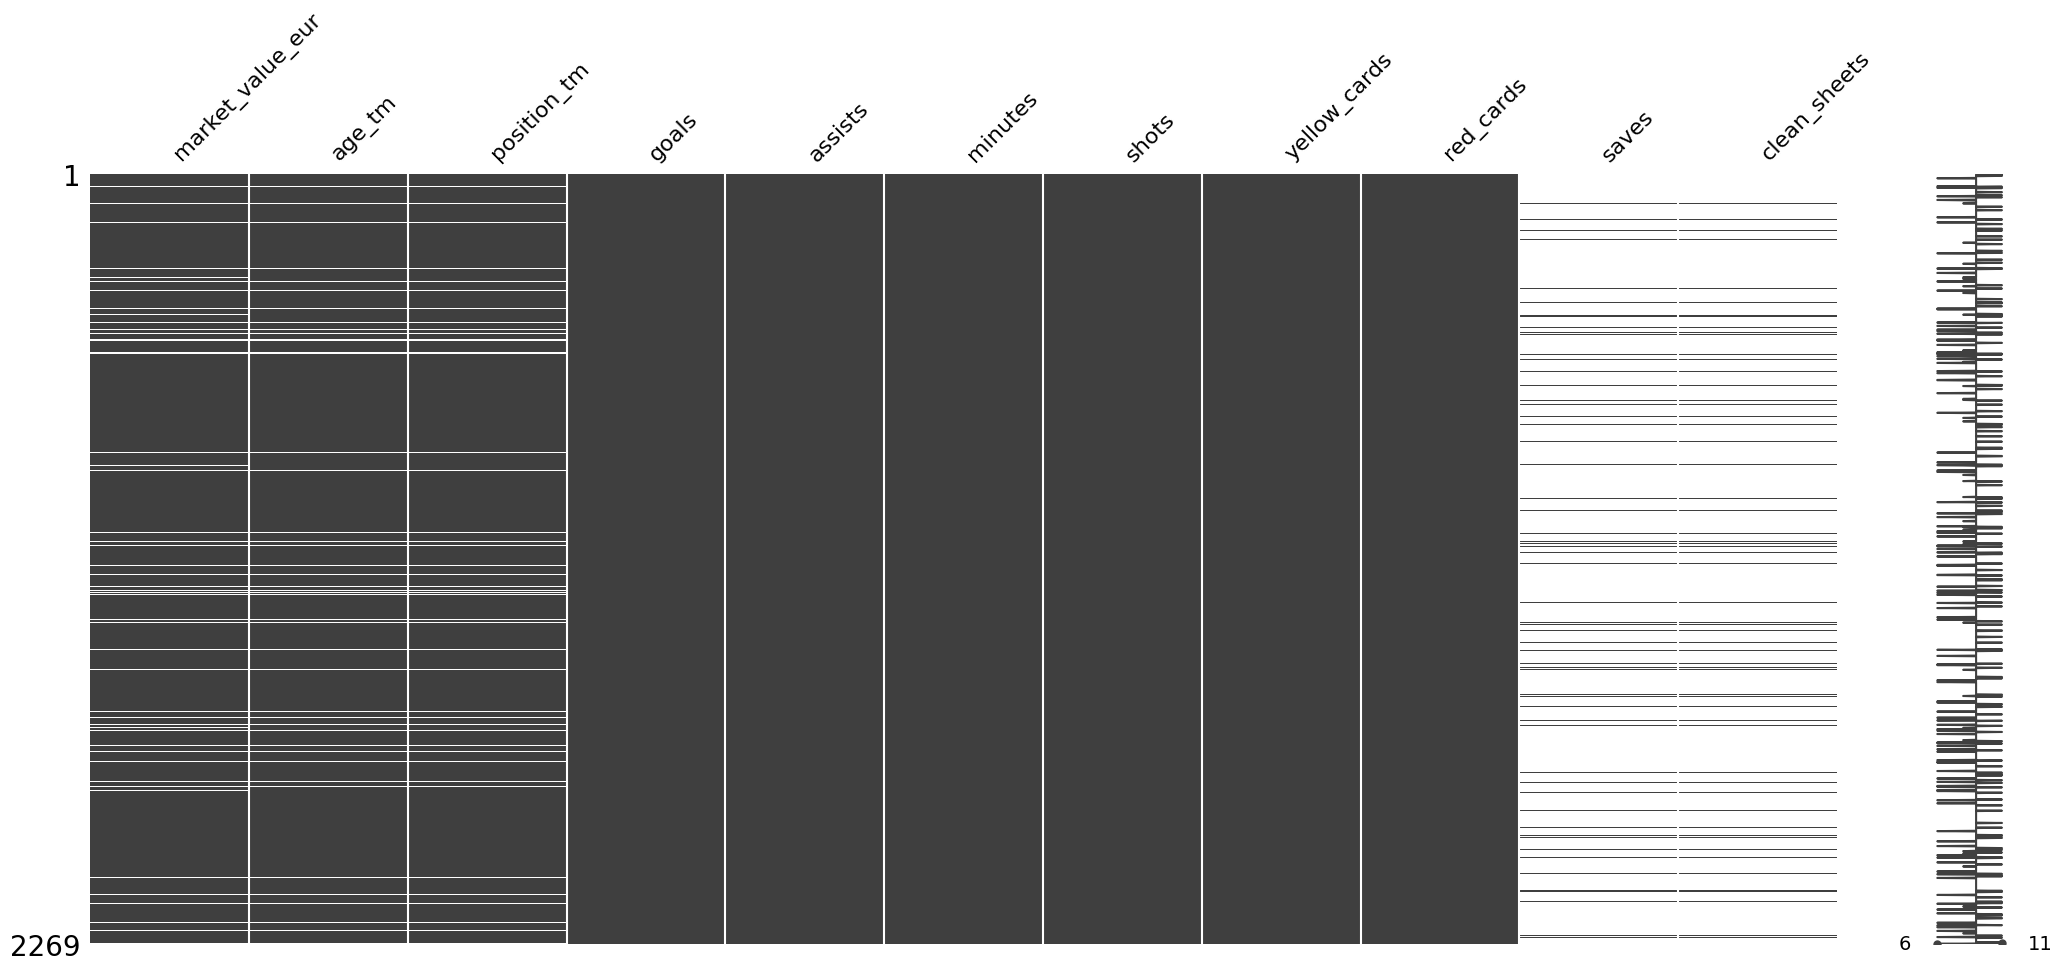

In [33]:
msno.matrix(merged)

important_cols = [
    "market_value_eur",
    "age_tm",
    "position_tm",
    "goals",
    "assists",
    "minutes",
    "shots",
    "yellow_cards",
    "red_cards",
    "saves",
    "clean_sheets"
]

msno.matrix(merged[important_cols])

In [40]:
matched = merged[merged["market_value_eur"].notna()]
unmatched = merged[merged["market_value_eur"].isna()]

In [41]:
matched["age_fbref"].describe()

count    2116.000000
mean       25.321834
std         4.356666
min        15.000000
25%        22.000000
50%        25.000000
75%        28.000000
max        39.000000
Name: age_fbref, dtype: float64

In [42]:
unmatched["age_fbref"].describe()

count    152.000000
mean      23.177632
std        5.062656
min       15.000000
25%       19.000000
50%       23.000000
75%       26.250000
max       39.000000
Name: age_fbref, dtype: float64

In [43]:
matched["minutes"].describe()

count    2116.000000
mean     1343.729206
std      1022.243754
min         1.000000
25%       381.250000
50%      1220.500000
75%      2162.500000
max      3420.000000
Name: minutes, dtype: float64

In [44]:
unmatched["minutes"].describe()

count     153.000000
mean     1052.679739
std      1106.606195
min         1.000000
25%        77.000000
50%       679.000000
75%      1792.000000
max      3420.000000
Name: minutes, dtype: float64

In [45]:
print(len(matched))

2116


In [46]:
print(len(unmatched))

153


In [47]:
matched["age_fbref"].describe()

count    2116.000000
mean       25.321834
std         4.356666
min        15.000000
25%        22.000000
50%        25.000000
75%        28.000000
max        39.000000
Name: age_fbref, dtype: float64

In [48]:
unmatched["age_fbref"].describe()

count    152.000000
mean      23.177632
std        5.062656
min       15.000000
25%       19.000000
50%       23.000000
75%       26.250000
max       39.000000
Name: age_fbref, dtype: float64

In [49]:
matched["position_fbref"].value_counts(normalize=True)

position_fbref
MF       0.312854
DF       0.261815
FW       0.120510
MF,FW    0.075614
GK       0.072779
FW,MF    0.064272
DF,MF    0.058601
MF,DF    0.032136
DF,FW    0.001418
Name: proportion, dtype: float64

In [50]:
unmatched["position_fbref"].value_counts(normalize=True)

position_fbref
DF       0.307190
MF       0.300654
FW,MF    0.091503
GK       0.071895
FW       0.065359
DF,MF    0.065359
MF,FW    0.065359
MF,DF    0.032680
Name: proportion, dtype: float64

In [51]:
unmatched[
    [
        "player_name",
        "club",
        "season",
        "minutes",
        "position_fbref",
        "age_fbref"
    ]
].sample(20, random_state=42)

,player_name,club,season,minutes,position_fbref,age_fbref
1233,benicio boaitey,Brighton,2324.0,40,FW,19.0
1263,benson manuel,Burnley,2324.0,116,MF,26.0
1494,ethan wheatley,Manchester Utd,2324.0,16,FW,17.0
1701,gabriel magalhaes,Arsenal,2425.0,2363,DF,26.0
488,oghenekaro etebo,Watford,2122.0,401,MF,25.0
1694,toti gomes,Wolves,2324.0,2772,DF,24.0
1151,jaden philogene bidace,Aston Villa,2324.0,4,"FW,MF",21.0
1181,illia zabarnyi,Bournemouth,2324.0,3330,DF,20.0
343,hannibal mejbri,Manchester Utd,2122.0,68,MF,18.0
308,ederson moraes,Manchester City,2122.0,3330,GK,27.0


In [52]:
unmatched.groupby("season").size()

season
2122.0    39
2223.0    38
2324.0    38
2425.0    38
dtype: int64

In [53]:
unmatched.groupby("club").size().sort_values(ascending=False).head(20)

club
Wolves              17
Tottenham           13
Brentford           11
West Ham            10
Liverpool           10
Manchester City      9
Aston Villa          9
Southampton          8
Brighton             7
Manchester Utd       7
Chelsea              7
Bournemouth          6
Leicester City       6
Arsenal              5
Nottingham           4
Watford              4
Norwich City         3
Sheffield United     3
Burnley              3
Luton Town           2
dtype: int64

In [54]:
unmatched["position_tm"].value_counts(dropna=False)

position_tm
NaN                   126
Right Winger            5
Left Winger             5
Defensive Midfield      5
Central Midfield        3
Centre-Back             2
Attacking Midfield      2
Right-Back              2
Centre-Forward          2
Left-Back               1
Name: count, dtype: int64

In [55]:
merged.assign(
    market_value_available=merged["market_value_eur"].notna()
).groupby("season")["market_value_available"].agg(
    ["count", "sum", "mean"]
)

,count,sum,mean
season,,,
2122.0,546,507,0.928571
2223.0,569,531,0.933216
2324.0,580,542,0.934483
2425.0,574,536,0.933798


## Correlation Analysis

In [38]:
eda = merged[
    [
        "market_value_eur",
        "age_fbref",
        "minutes",
        "goals",
        "assists",
        "shots",
        "goal_contributions",
        "position_tm"
    ]
].copy()

In [39]:
eda.describe()

,market_value_eur,age_fbref,minutes,goals,assists,shots,goal_contributions
count,2.116000e+03,2268.000000,2269.000000,2269.000000,2269.000000,2269.000000,2269.000000
mean,1.946745e+07,25.178131,1324.103570,1.918907,1.381225,17.484795,3.300132
std,2.076568e+07,4.438773,1030.479065,3.498367,2.204017,22.078870,5.116742
min,7.500000e+04,15.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,5.000000e+06,22.000000,354.000000,0.000000,0.000000,2.000000,0.000000
50%,1.400000e+07,25.000000,1170.000000,0.000000,0.000000,9.000000,1.000000
75%,2.500000e+07,28.000000,2154.000000,2.000000,2.000000,25.000000,4.000000
max,1.800000e+08,39.000000,3420.000000,36.000000,18.000000,139.000000,47.000000


In [40]:
corr = eda.drop(columns="position_tm").corr(numeric_only=True)

corr["market_value_eur"].sort_values(ascending=False)

market_value_eur      1.000000
goal_contributions    0.614212
shots                 0.602657
goals                 0.569919
assists               0.520971
minutes               0.465451
age_fbref            -0.190963
Name: market_value_eur, dtype: float64

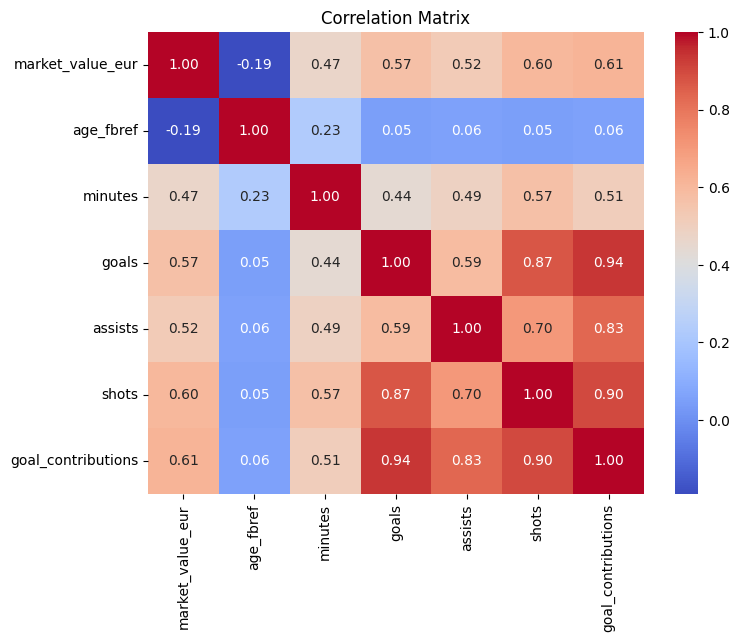

In [41]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

In [42]:
merged.groupby("position_tm")["market_value_eur"].describe()

,count,mean,std,min,25%,50%,75%,max
position_tm,,,,,,,,
Attacking Midfield,161.0,2.845621e+07,2.909038e+07,100000.0,7500000.0,20000000.0,40000000.0,150000000.0
Central Midfield,274.0,1.826232e+07,2.004331e+07,200000.0,5000000.0,13000000.0,25000000.0,120000000.0
Centre-Back,392.0,1.816314e+07,1.653835e+07,100000.0,5000000.0,14000000.0,25000000.0,80000000.0
Centre-Forward,277.0,2.011336e+07,2.619938e+07,150000.0,4000000.0,12000000.0,25000000.0,180000000.0
Defensive Midfield,188.0,2.174362e+07,2.031952e+07,500000.0,7000000.0,17000000.0,30000000.0,120000000.0
Goalkeeper,154.0,1.050779e+07,1.052426e+07,200000.0,2000000.0,7000000.0,18000000.0,50000000.0
Left Midfield,13.0,8.338462e+06,6.596658e+06,200000.0,4000000.0,7000000.0,12000000.0,23000000.0
Left Winger,169.0,2.443757e+07,2.069848e+07,75000.0,9000000.0,20000000.0,35000000.0,80000000.0
Left-Back,143.0,1.576853e+07,1.227062e+07,100000.0,5000000.0,13000000.0,25000000.0,45000000.0


In [43]:
numeric_cols = merged.select_dtypes(include="number")

corr = (
    numeric_cols
    .corr(numeric_only=True)["market_value_eur"]
    .sort_values(ascending=False)
)

corr.head(20)

market_value_eur           1.000000
wins                       0.742080
clean_sheets               0.690988
team_goals                 0.616821
goal_contributions         0.614212
shots                      0.602657
shots_on_target            0.584529
goals                      0.569919
non_penalty_goals          0.563447
draws                      0.551033
assists                    0.520971
saves                      0.510524
goal_difference            0.496632
shots_on_target_against    0.491180
starts                     0.468190
fouls_drawn                0.467099
minutes_pct                0.465474
nineties                   0.465454
minutes                    0.465451
matches_played             0.448913
Name: market_value_eur, dtype: float64

In [6]:
merged["age_fbref"].describe()

count    2268.000000
mean       25.178131
std         4.438773
min        15.000000
25%        22.000000
50%        25.000000
75%        28.000000
max        39.000000
Name: age_fbref, dtype: float64

## Playing position Grouping

- This is necessary for the position-specific modelling of the project

In [4]:
position_mapping = {
    "Centre-Forward": "Attacker",
    "Second Striker": "Attacker",
    "Left Winger": "Attacker",
    "Right Winger": "Attacker",

    "Attacking Midfield": "Midfielder",
    "Central Midfield": "Midfielder",
    "Defensive Midfield": "Midfielder",
    "Left Midfield": "Midfielder",
    "Right Midfield": "Midfielder",

    "Centre-Back": "Defender",
    "Left-Back": "Defender",
    "Right-Back": "Defender",

    "Goalkeeper": "Goalkeeper"
}

merged["position_group"] = merged["position_tm"].map(position_mapping)

In [4]:
merged.head()

,league,season,club,player_name,nation,position_fbref,age_fbref,born,matches_played,starts,...,clean_sheet_percentage,penalties_faced,penalties_saved,penalties_missed,penalties_conceded,penalty_save_percentage,position_tm,age_tm,market_value_eur,position_group
0,ENG-Premier League,2122.0,Arsenal,aaron ramsdale,ENG,GK,23.0,1998.0,34,34,...,35.3,6.0,5.0,0.0,1.0,0.0,Goalkeeper,24.0,28000000.0,Goalkeeper
1,ENG-Premier League,2122.0,Arsenal,ainsley maitland niles,ENG,MF,23.0,1997.0,8,2,...,NaN,NaN,NaN,NaN,NaN,NaN,Right-Back,24.0,10000000.0,Defender
2,ENG-Premier League,2122.0,Arsenal,albert sambi lokonga,BEL,MF,21.0,1999.0,19,12,...,NaN,NaN,NaN,NaN,NaN,NaN,Central Midfield,22.0,14000000.0,Midfielder
3,ENG-Premier League,2122.0,Arsenal,alexandre lacazette,FRA,"FW,MF",30.0,1991.0,30,20,...,NaN,NaN,NaN,NaN,NaN,NaN,Centre-Forward,31.0,15000000.0,Attacker
4,ENG-Premier League,2122.0,Arsenal,ben white,ENG,DF,23.0,1997.0,32,32,...,NaN,NaN,NaN,NaN,NaN,NaN,Right-Back,24.0,40000000.0,Defender


In [5]:
merged["position_group"].value_counts(dropna=False)

position_group
Defender      728
Midfielder    655
Attacker      606
Goalkeeper    154
NaN           126
Name: count, dtype: int64

In [6]:
merged[merged["position_tm"].isna()][
    ["player_name", "club", "season", "market_value_eur"]
].head(20)

,player_name,club,season,market_value_eur
12,gabriel magalhaes,Arsenal,2122.0,NaN
36,emi buendia,Aston Villa,2122.0,NaN
40,jaden philogene bidace,Aston Villa,2122.0,NaN
65,finley stevens,Brentford,2122.0,NaN
76,mathias jrgensen,Brentford,2122.0,NaN
86,alvaro fernandez,Brentford,2122.0,NaN
127,johann berg gumundsson,Burnley,2122.0,NaN
142,emerson palmieri,Chelsea,2122.0,NaN
233,leo fuhr hjelde,Leeds United,2122.0,NaN
278,andy robertson,Liverpool,2122.0,NaN


## Final Dataset For modelling

In [5]:
final_model_data = merged[
    merged["market_value_eur"].notna() &
    merged["position_group"].notna()
].copy()

In [6]:
len(merged) - len(final_model_data)

153

##

In [7]:
final_model_data.columns

Index(['league', 'season', 'club', 'player_name', 'nation', 'position_fbref',
       'age_fbref', 'born', 'matches_played', 'starts', 'minutes', 'nineties',
       'goals', 'assists', 'goal_contributions', 'non_penalty_goals',
       'penalty_goals', 'penalty_attempts', 'yellow_cards', 'red_cards',
       'goals_per90', 'assists_per90', 'ga_per90', 'npg_per90', 'npga_per90',
       'shots', 'shots_on_target', 'shots_on_target_pct', 'shots_per90',
       'shots_on_target_per90', 'goals_per_shot', 'goals_per_shot_on_target',
       'minutes_per_match', 'minutes_pct', 'starts_per_match',
       'complete_matches', 'substitute_appearances', 'minutes_per_sub',
       'unused_substitute', 'points_per_match', 'team_goals',
       'team_goals_against', 'goal_difference', 'goal_difference_per90',
       'on_off', 'second_yellows', 'fouls_committed', 'fouls_drawn',
       'offsides', 'crosses', 'interceptions', 'tackles_won', 'own_goals',
       'goals_against', 'goals_against_per90', 'shots_on_

In [8]:
final_model_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2116 entries, 0 to 2268
Data columns (total 72 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   league                    2116 non-null   object 
 1   season                    2116 non-null   float64
 2   club                      2116 non-null   object 
 3   player_name               2116 non-null   object 
 4   nation                    2115 non-null   object 
 5   position_fbref            2116 non-null   object 
 6   age_fbref                 2116 non-null   float64
 7   born                      2116 non-null   float64
 8   matches_played            2116 non-null   int64  
 9   starts                    2116 non-null   int64  
 10  minutes                   2116 non-null   int64  
 11  nineties                  2116 non-null   float64
 12  goals                     2116 non-null   int64  
 13  assists                   2116 non-null   int64  
 14  goal_contribu

In [9]:
feature_eng = pd.DataFrame({
    "dtype": final_model_data.dtypes,
    "missing": final_model_data.isna().sum(),
    "missing_pct": final_model_data.isna().mean() * 100,
    "unique_values": final_model_data.nunique()
})

feature_eng

,dtype,missing,missing_pct,unique_values
league,object,0,0.000000,1
season,float64,0,0.000000,4
club,object,0,0.000000,26
player_name,object,0,0.000000,1017
nation,object,1,0.047259,79
...,...,...,...,...
penalty_save_percentage,float64,2012,95.085066,10
position_tm,object,0,0.000000,13
age_tm,float64,0,0.000000,25
market_value_eur,float64,0,0.000000,79


In [18]:
feature_eng.to_string()

'                            dtype  missing  missing_pct  unique_values\nleague                     object        0     0.000000              1\nseason                    float64        0     0.000000              4\nclub                       object        0     0.000000             26\nplayer_name                object        0     0.000000           1017\nnation                     object        1     0.047259             79\nposition_fbref             object        0     0.000000              9\nage_fbref                 float64        0     0.000000             25\nborn                      float64        0     0.000000             27\nmatches_played              int64        0     0.000000             38\nstarts                      int64        0     0.000000             39\nminutes                     int64        0     0.000000           1403\nnineties                  float64        0     0.000000            374\ngoals                       int64        0     0.000000        

In [10]:
common_features = [
    "age_fbref",
    "matches_played",
    "starts",
    "minutes",
    "goals",
    "assists",
    "goal_contributions",
    "non_penalty_goals",
    "penalty_goals",
    "penalty_attempts",
    "yellow_cards",
    "red_cards",
    "goals_per90",
    "assists_per90",
    "ga_per90",
    "npg_per90",
    "npga_per90",
    "shots",
    "shots_on_target",
    "shots_on_target_pct",
    "shots_per90",
    "shots_on_target_per90",
    "goals_per_shot",
    "goals_per_shot_on_target",
    "minutes_per_match",
    "minutes_pct",
    "starts_per_match",
    "complete_matches",
    "substitute_appearances",
    "minutes_per_sub",
    "unused_substitute",
    "points_per_match",
    "team_goals",
    "team_goals_against",
    "goal_difference",
    "goal_difference_per90",
    "on_off",
    "second_yellows",
    "fouls_committed",
    "fouls_drawn",
    "offsides",
    "crosses",
    "interceptions",
    "tackles_won",
    "own_goals"
]

goalkeeper_features = [
    "age_fbref",
    "matches_played",
    "starts",
    "minutes",
    "team_goals",
    "team_goals_against",
    "goal_difference",
    "goals_against",
    "goals_against_per90",
    "shots_on_target_against",
    "saves",
    "save_percentage",
    "wins",
    "draws",
    "losses",
    "clean_sheets",
    "clean_sheet_percentage",
    "penalties_faced",
    "penalties_saved",
    "penalties_missed",
    "penalties_conceded",
    "penalty_save_percentage"
]

In [13]:
missing_common = final_model_data[
    common_features
].isna().sum()

miss_var = missing_common[missing_common > 0]
miss_var

shots_on_target_pct         369
goals_per_shot              369
goals_per_shot_on_target    605
starts_per_match            244
minutes_per_sub             339
on_off                       17
dtype: int64

In [14]:
for col in miss_var.index:
    print(f"\n--- {col} ---")
    print(
        final_model_data[
            final_model_data[col].isna()
        ][
            [
                "player_name",
                "position_group",
                "minutes",
                "matches_played",
                "shots",
                "shots_on_target",
                col
            ]
        ].head()
    )


--- shots_on_target_pct ---
          player_name position_group  minutes  matches_played  shots  \
0      aaron ramsdale     Goalkeeper     3060              34      0   
5          bernd leno     Goalkeeper      360               4      0   
24     sead kolasinac       Defender       91               2      0   
37  emiliano martinez     Goalkeeper     3240              36      0   
41          jed steer     Goalkeeper       90               1      0   

    shots_on_target  shots_on_target_pct  
0                 0                  NaN  
5                 0                  NaN  
24                0                  NaN  
37                0                  NaN  
41                0                  NaN  

--- goals_per_shot ---
          player_name position_group  minutes  matches_played  shots  \
0      aaron ramsdale     Goalkeeper     3060              34      0   
5          bernd leno     Goalkeeper      360               4      0   
24     sead kolasinac       Defender    

## Features excluded

An assessment of missing values was conducted for the candidate predictor variables. Six variables contained missing values:
- shots_on_target_pct
- goals_per_shot
- goals_per_shot_on_target
- starts_per_match
- minutes_per_sub
- on_off

The missing values in the shooting-related variables were primarily associated with zero denominators. Specifically, shots_on_target_pct and goals_per_shot were undefined for observations where players recorded no shots, while goals_per_shot_on_target was undefined when players recorded no shots on target. Similarly, missing values in starts_per_match and minutes_per_sub reflected situations where the relevant denominator was zero, such as players who made appearances without starting or players who did not appear as substitutes. The on_off variable contained only a small number of missing observations.

In [16]:
common_features = [
    "age_fbref",
    "matches_played",
    "starts",
    "minutes",
    "goals",
    "assists",
    "goal_contributions",
    "non_penalty_goals",
    "penalty_goals",
    "penalty_attempts",
    "yellow_cards",
    "red_cards",
    "goals_per90",
    "assists_per90",
    "ga_per90",
    "npg_per90",
    "npga_per90",
    "shots",
    "shots_on_target",
    "shots_per90",
    "shots_on_target_per90",
    "minutes_per_match",
    "minutes_pct",
    "complete_matches",
    "substitute_appearances",
    "unused_substitute",
    "points_per_match",
    "team_goals",
    "team_goals_against",
    "goal_difference",
    "goal_difference_per90",
    "second_yellows",
    "fouls_committed",
    "fouls_drawn",
    "offsides",
    "crosses",
    "interceptions",
    "tackles_won",
    "own_goals"
]

final_model_data[common_features].isna().sum().sort_values(ascending=False).head()

age_fbref                 0
goal_difference           0
minutes_pct               0
complete_matches          0
substitute_appearances    0
dtype: int64

In [18]:
final_model_data.groupby("position_group")[common_features].mean()

,age_fbref,matches_played,starts,minutes,goals,assists,goal_contributions,non_penalty_goals,penalty_goals,penalty_attempts,...,goal_difference,goal_difference_per90,second_yellows,fouls_committed,fouls_drawn,offsides,crosses,interceptions,tackles_won,own_goals
position_group,,,,,,,,,,,,,,,,,,,,,
Attacker,24.430976,20.314815,12.885522,1171.365320,4.151515,2.090909,6.242424,3.781145,0.370370,0.451178,...,0.734007,-0.089747,0.021886,14.489899,17.855219,5.801347,26.720539,4.789562,8.604377,0.010101
Defender,25.645920,19.311203,16.065007,1441.125864,0.699862,0.871369,1.571231,0.699862,0.000000,0.000000,...,-0.478562,-0.248700,0.060858,13.947441,10.961272,1.055325,21.744122,17.598893,17.060858,0.149378
Goalkeeper,28.798701,18.272727,18.051948,1626.253247,0.000000,0.084416,0.084416,0.000000,0.000000,0.000000,...,-1.188312,-0.375519,0.000000,0.370130,2.292208,0.000000,0.000000,0.246753,0.350649,0.110390
Midfielder,24.948837,20.979845,14.906977,1325.834109,1.846512,1.727132,3.573643,1.697674,0.148837,0.179845,...,0.108527,0.042372,0.041860,19.258915,17.303876,1.358140,29.006202,13.530233,17.922481,0.034109


## Log Transformation Of Market Value


In [20]:
final_model_data[['market_value_eur']].head()

,market_value_eur
0,28000000.0
1,10000000.0
2,14000000.0
3,15000000.0
4,40000000.0


In [21]:
final_model_data["log_market_value"] = np.log1p(
    final_model_data["market_value_eur"]
)

In [23]:
final_model_data[['log_market_value']].head()

,log_market_value
0,17.147715
1,16.118096
2,16.454568
3,16.523561
4,17.504390


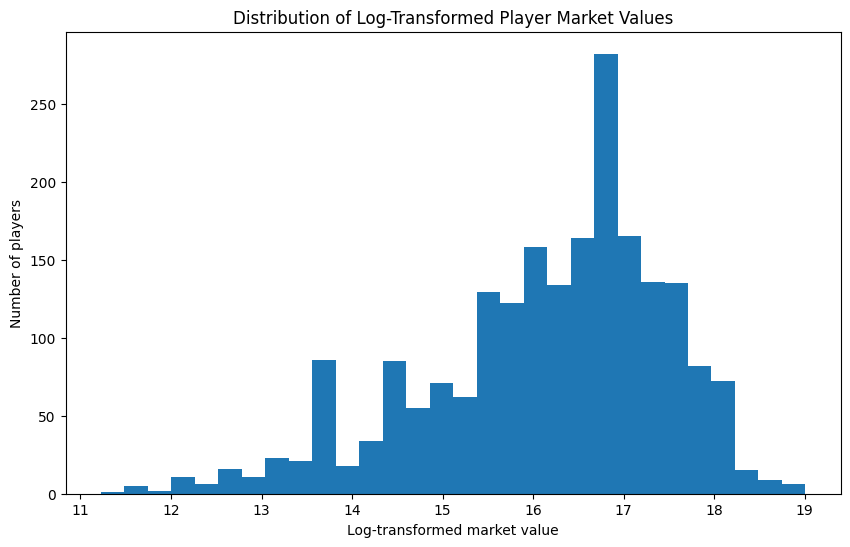

In [25]:
plt.figure(figsize=(10, 6))

plt.hist(
    final_model_data["log_market_value"],
    bins=30
)

plt.xlabel("Log-transformed market value")
plt.ylabel("Number of players")
plt.title("Distribution of Log-Transformed Player Market Values")

plt.show()

In [17]:
final_model_data.to_csv(
    "/Users/kachi/Documents/Thesis/data/processed/final_model_data.csv",
    index=False
)

In [24]:
final_model_data.to_csv(
    "/Users/kachi/Documents/Thesis/data/processed/final_model_data_with_log.csv",
    index=False
)